In [1]:
import json
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np
from deep_peep_snooker import config
from deep_peep_snooker.utils.annotations import PlayfieldAnnotationCollection
from deep_peep_snooker.utils.func import read_image_as_numpyimage
from deep_peep_snooker.utils.playfield_finder import PlayfieldFinder
from deep_peep_snooker.utils.plotting import display_img
from deep_peep_snooker.utils.const import BALLS
from deep_peep_snooker.schemas.ball import BallColor

In [2]:
leaded_clean = PlayfieldAnnotationCollection.from_clean_file('data/playfield_gt.json')
picname = 'pic_01_02_01.png' # pic_01_30_01              pic_01_02_01

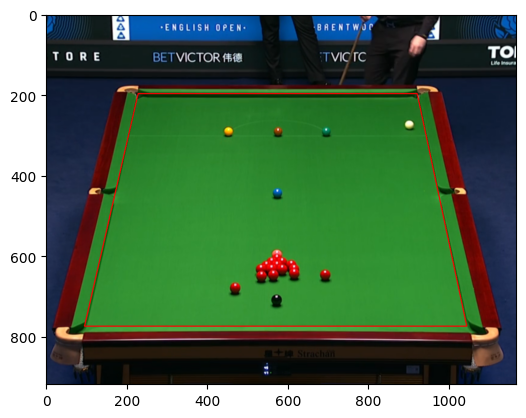

In [3]:
img = read_image_as_numpyimage(f'data/pics/{picname}')
ann = leaded_clean.filter_by_image(picname)

finder = PlayfieldFinder(img)
playfield = finder.detect_inner_playfield()

display_img(playfield.display_on_image(img))

In [4]:
mask = np.zeros((img.height, img.width), dtype=np.uint8)

In [5]:
cv2.fillPoly(mask, [playfield.points.to_numpy()], 255)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(918, 1168), dtype=uint8)

In [6]:
mask = np.dstack((mask, mask, mask))

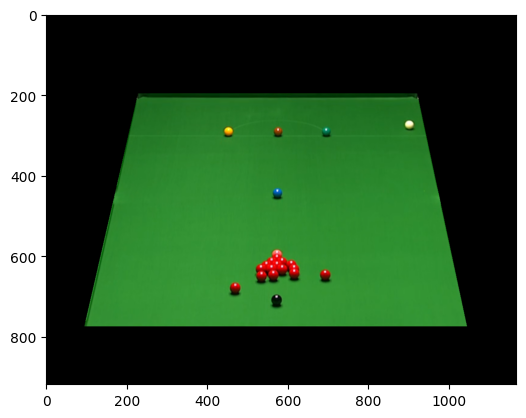

In [7]:
masked_img = img & mask
display_img(masked_img)

In [8]:
cropped_img = masked_img[
    playfield.points.top_left.y: playfield.points.bottom_left.y + 1,
    playfield.points.bottom_left.x: playfield.points.bottom_right.x + 1,
    ]

cropped_img_hsv = cv2.cvtColor(cropped_img, cv2.COLOR_RGB2HSV)

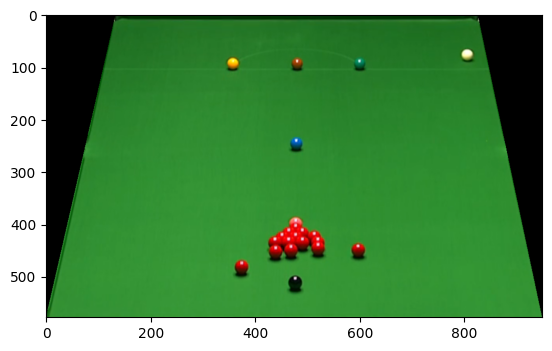

In [9]:
display_img(cropped_img)

In [10]:
r = BALLS.range_for(BallColor.BLUE)
bin_img = cv2.inRange(cropped_img_hsv, r.lower_bound, r.upper_bound)

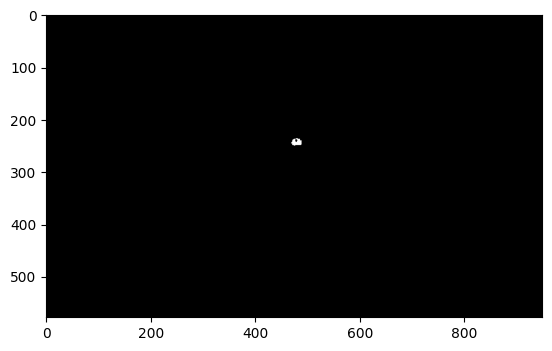

In [11]:
display_img(bin_img)

In [12]:
cnt, _ = cv2.findContours(bin_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

In [13]:
if cnt is None:
    raise Exception('nie ma tej bili')

else:
    cnt = cnt[0]

In [14]:
cnt

array([[[478, 237]],

       [[477, 238]],

       [[476, 238]],

       [[475, 238]],

       [[474, 238]],

       [[473, 239]],

       [[472, 239]],

       [[472, 240]],

       [[471, 241]],

       [[471, 242]],

       [[471, 243]],

       [[470, 244]],

       [[469, 245]],

       [[469, 246]],

       [[470, 246]],

       [[471, 247]],

       [[471, 248]],

       [[471, 249]],

       [[472, 249]],

       [[473, 249]],

       [[474, 250]],

       [[475, 250]],

       [[476, 250]],

       [[477, 249]],

       [[478, 249]],

       [[479, 249]],

       [[480, 249]],

       [[481, 249]],

       [[482, 249]],

       [[483, 249]],

       [[484, 249]],

       [[485, 249]],

       [[486, 249]],

       [[487, 249]],

       [[488, 248]],

       [[488, 247]],

       [[488, 246]],

       [[488, 245]],

       [[488, 244]],

       [[488, 243]],

       [[488, 242]],

       [[488, 241]],

       [[487, 241]],

       [[486, 241]],

       [[485, 240]],

       [[4

In [15]:
x, y, w, h = cv2.boundingRect(cnt)

In [16]:
h_up = 2*h
h_low = int(h * 0.25)

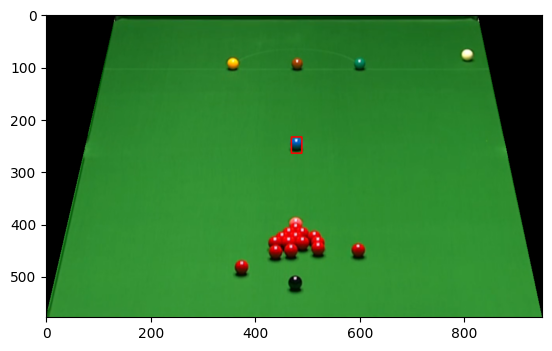

In [17]:
display_img(cv2.rectangle(cropped_img.copy(), (x, y - h_low), (x + w, y + h_up), (255, 0, 0), thickness=2))

In [18]:
roi_hsv = cropped_img_hsv[
    y - int(h * 0.25): y+h_up + 1,
    x: x+ w + 1
]
roi = cropped_img[
    y-int(h * 0.25): y+h_up + 1,
    x: x+ w + 1
]

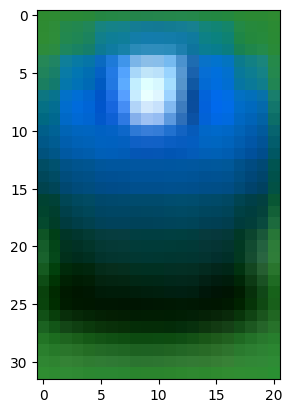

In [19]:
display_img(roi)

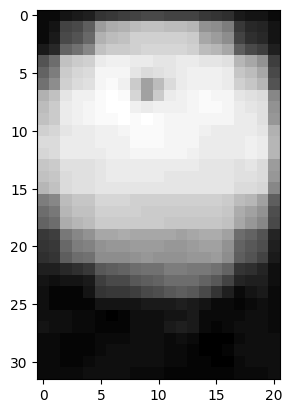

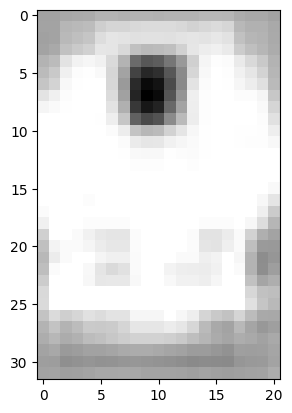

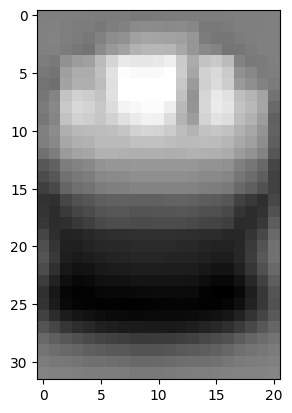

In [20]:
display_img(roi_hsv[..., 0])
display_img(roi_hsv[..., 1])
display_img(roi_hsv[..., 2])

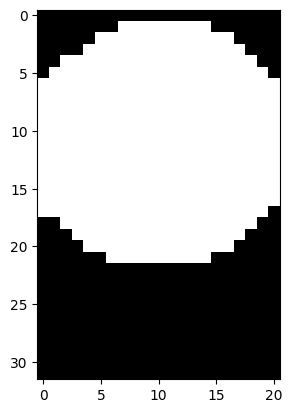

In [21]:


med = cv2.medianBlur(roi_hsv[..., 0], 7)

_, th = cv2.threshold(med, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

display_img(th)

In [22]:
cnt2 = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)[0][0]

In [23]:
x, y, w, h = cv2.boundingRect(cnt2)

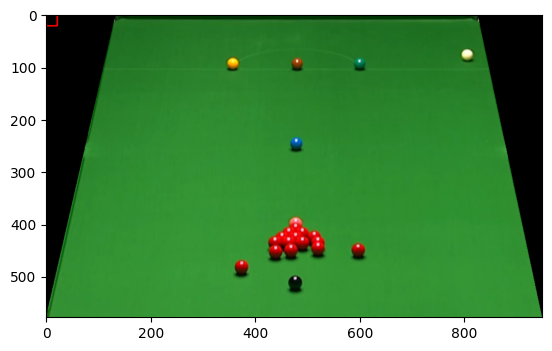

In [24]:
display_img(cv2.rectangle(cropped_img.copy(), (x, y), (x + w, y + h), (255, 0, 0), thickness=2))